In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import gc
import warnings
warnings.filterwarnings('ignore')
import logging

from sklearn import metrics

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional, \
                        Conv1D, Flatten,MaxPooling1D, ConvLSTM2D, \
                        TimeDistributed, RepeatVector, Bidirectional, BatchNormalization
from keras.optimizers import Adam

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)

ROOT = pathlib.Path().resolve()
DATA_FOLDER = ROOT / "data/bike"
LOG_FILE = ROOT / "logs/info.log"

# Gets or creates a logger
sub_log = logging.getLogger(__name__)  
sub_log.setLevel(logging.INFO)

# define file handler and set formatter
file_handler = logging.FileHandler('logs/sub_data.log')
formatter    = logging.Formatter('%(asctime)s : %(levelname)s : %(name)s : %(message)s')
file_handler.setFormatter(formatter)

# add file handler to logger
sub_log.addHandler(file_handler)


print(DATA_FOLDER)

C:\Users\PatCa\Documents\PythonScripts\test_projects\big_data\bike_data\data\bike


In [22]:
# Open cleaned data
df = pd.read_parquet('all_years_weekly.parquet')

# Get date col
df['date'] = df.index

# Get week number col
df['week_number'] = df['date'].dt.isocalendar().week.astype(int)
df['row_count'] = np.array([i for i in range(df.shape[0])])

# Log data
df['log_trips'] = df['count_trips'].apply(lambda x: np.log(x))

# Make stationary
df['log_trips_shift'] = df['log_trips'].diff()

display(df.head(3))

test_length = int(df.shape[0] * 0.1)
train = df.iloc[:-test_length,:].dropna()
test = df.iloc[-test_length:,:].dropna()

,count_trips,start_tripduration,date,week_number,row_count,log_trips,log_trips_shift
starttime,,,,,,,
2014-01-05,19855,16052099,2014-01-05,1,0,9.896211,NaN
2014-01-12,66987,45280072,2014-01-12,2,1,11.112254,1.216043
2014-01-19,107472,74364131,2014-01-19,3,2,11.584986,0.472732


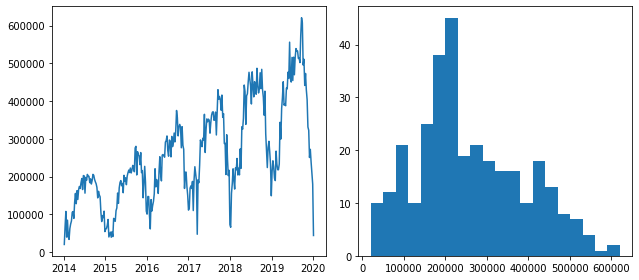

In [23]:
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
plt.plot(df.index, df.count_trips)
plt.subplot(1,2,2)
plt.hist(df.count_trips, bins=20)
plt.tight_layout()
plt.show()

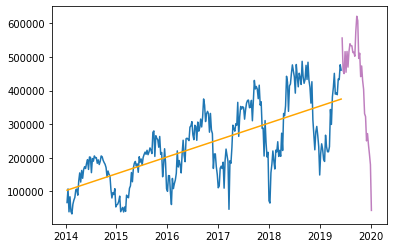

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

xx = [i for i in range(train.shape[0])]
xxx = np.array(xx).reshape(-1,1)
y = train['count_trips'].to_numpy()
trend = LinearRegression()
trend.fit(xxx,y)

x_trend = trend.predict(xxx)
df_trend = pd.DataFrame(data=x_trend, index=train.index, columns=['trend'])

plt.figure()
plt.plot(train.index, train['count_trips'])
plt.plot(test.index, test['count_trips'], color='purple', alpha=0.5)
plt.plot(train.index, df_trend.trend, color='orange')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

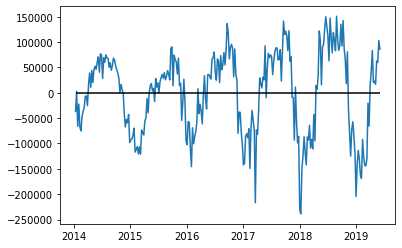

In [25]:
train['detrend'] = train['count_trips'] - df_trend['trend']

plt.figure()
plt.plot(train.index, train.detrend)
plt.hlines(0, train.index[0], train.index[-1], color='black')
plt.show

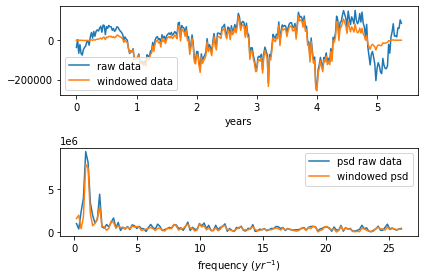

In [26]:
# Use fft to check seasonality component
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import rfft, rfftfreq
from scipy.signal import tukey

from numpy.fft import fft, fftshift
import pandas as pd

a_gtrend_orig = train.detrend
t_gtrend_orig = np.linspace( 0, len(a_gtrend_orig)/52, len(a_gtrend_orig), endpoint=False )

a_gtrend_windowed = (a_gtrend_orig - np.median( a_gtrend_orig ))*tukey( len(a_gtrend_orig) )

plt.subplot( 2, 1, 1 )
plt.plot( t_gtrend_orig, a_gtrend_orig, label='raw data'  )
plt.plot( t_gtrend_orig, a_gtrend_windowed, label='windowed data' )
plt.xlabel( 'years' )
plt.legend()

a_gtrend_psd = abs(rfft( a_gtrend_orig ))
a_gtrend_psdtukey = abs(rfft( a_gtrend_windowed ) )

# Notice that we assert the delta-time here,
# It would be better to get it from the data.
a_gtrend_freqs = rfftfreq( len(a_gtrend_orig), d = 1./52. )

# For the PSD graph, we skip the first two points, this brings us more into a useful scale
# those points represent the baseline (or mean), and are usually not relevant to the analysis
plt.subplot( 2, 1, 2 )
plt.plot( a_gtrend_freqs[1:], a_gtrend_psd[1:], label='psd raw data' )
plt.plot( a_gtrend_freqs[1:], a_gtrend_psdtukey[1:], label='windowed psd' )
plt.xlabel( 'frequency ($yr^{-1}$)' )
plt.legend()

plt.tight_layout()
plt.show()

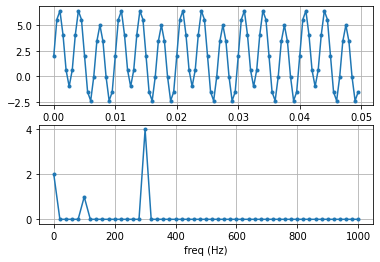

In [27]:
# FFT test
# Set up constants and signal
Fs = 2000 # Sampling frequency
tstep = 1 / Fs # sample time interval
f0 = 100 # signal frequency

N = int(5 * Fs / f0) # Number of samples

t = np.linspace(0, (N-1)*tstep, N) # Time steps
fstep = Fs / N # Frequency interval
f = np.linspace(0, (N-1)*fstep, N) # Frequency steps

y = 1 * np.sin(2 * np.pi * f0 * t) + 4 * np.sin(2 * np.pi * 3 * f0 * t) + 2

# FFT
X = np.fft.fft(y)
X_mag = np.abs(X) / N

f_plot = f[0:int(N/2+1)]
X_mag_plot = 2 * X_mag[0:int(N/2+1)]
X_mag_plot[0] = X_mag_plot[0] / 2 # Note: DC component does not need mult by 2

fig, [ax1, ax2] = plt.subplots(nrows=2, ncols=1)
ax1.plot(t,y,'.-')
ax2.plot(f_plot, X_mag_plot, '.-')
ax1.set_xlabel('time (s)')
ax2.set_xlabel('freq (Hz)')
ax1.grid()
ax2.grid()
plt.show()



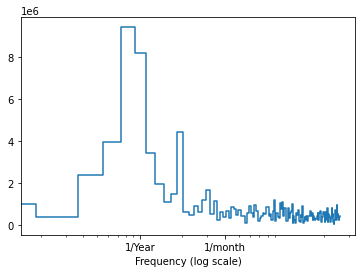

In [28]:
fft = tf.signal.rfft(train['detrend'])
f_per_dataset = np.arange(0, len(fft))

n_samples_w = len(train['detrend'])
weeks_per_year = 52
years_per_dataset = n_samples_w/(weeks_per_year)

f_per_year = f_per_dataset/years_per_dataset

plt.figure()
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.xticks([1, 4], labels=['1/Year', '1/month'])
plt.xlabel('Frequency (log scale)')
plt.show()


,count_trips,start_tripduration,date,week_number,row_count,log_trips,log_trips_shift,detrend,detrend_shift,deseason
starttime,,,,,,,,,,
2014-01-12,66987,45280072,2014-01-12,2,1,11.112254,1.216043,-36742.003734,202099.152747,438615.933376
2014-01-19,107472,74364131,2014-01-19,3,2,11.584986,0.472732,2778.779185,241619.935666,394941.445566
2014-01-26,39418,30976679,2014-01-26,4,3,10.581978,-1.003008,-66239.437895,172601.718586,285527.981864
2014-02-02,84278,60393006,2014-02-02,5,4,11.341876,0.759898,-22343.654976,216497.501505,398320.915690
2014-02-09,40244,38013273,2014-02-09,6,5,10.602716,-0.739160,-67341.872056,171499.284425,278570.496981


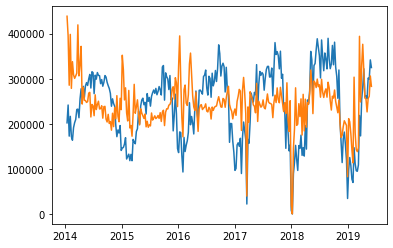

In [29]:
from sktime.transformations.series.detrend import Deseasonalizer

train["detrend_shift"] = train['detrend'].to_numpy() - train['detrend'].min() + 1
y = train["detrend_shift"].to_numpy()


transformer_a = Deseasonalizer(model="additive", sp=52)
transformer_m = Deseasonalizer(model="multiplicative", sp=52)

train['deseason'] = transformer_m.fit_transform(y)

display(train.head())

plt.figure()
plt.plot(train.index, train.detrend_shift)
plt.plot(train.index, train.deseason)
plt.show()


,trend,season,ffit
starttime,,,
2014-01-12,103729.003734,228889.224989,2.623089e-06
2014-01-19,104693.220815,230497.115866,2.304971e+05
2014-01-26,105657.437895,232011.204112,7.350562e+06


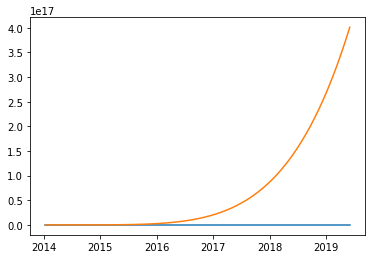

In [30]:
from numpy import polyfit
import numpy.polynomial.polynomial as poly

xx2 = train['row_count'].to_numpy()
y = train['detrend_shift'].to_numpy()

degrees = 5
z = polyfit(xx2,y,degrees)
p = np.poly1d(z)

x_new = np.array([i for i in range(xx2.shape[0])])
#coefs = poly.polyfit(x, y, 4)
ffit = poly.polyval(x_new, z)

zz = p(xx)
df_trend['season'] = zz
df_trend['ffit'] = ffit

display(df_trend.head(3))

plt.figure()
plt.plot(train.index, train.detrend)
plt.plot(train.index, ffit)
plt.show()
